# TDVP Gaussian Solver — Benchmark Notebook
Variational quantum dynamics with displaced-squeezed Gaussian ansatz.

**Solver:** `tdvp/solver.py` + `tdvp/gaussians.py`  
Sections: HO → Kerr → Cross-Kerr → Norm decay.


## Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tdvp.solver import (
    GaussianComponent, HierarchicalState, Nu,
    TDVPSolver, pack_state, rk4_step,
    apply_jump_spin_decay, apply_jump_displacement,
)
from tdvp.gaussians import single_mode_gaussians_expec

plt.rcParams.update({'figure.facecolor':'white','axes.grid':True,'grid.alpha':0.3,'lines.linewidth':2})

# ── helpers ──
def make_nus(sectors, n_gauss, n_modes):
    nus = []
    for s in sectors:
        for p in range(n_gauss):
            nus += [Nu(s,p,0,'kappa'), Nu(s,p,0,'theta')]
            for k in range(n_modes):
                for kind in ['x','y','r','phi']: nus.append(Nu(s,p,k,kind))
    return nus

def make_gaussians(alpha_c, n_gauss, suppress=0.0, seed=0):
    rng = np.random.default_rng(seed)
    ac = np.atleast_1d(alpha_c); nm_modes = len(ac)
    gs = []
    for _ in range(n_gauss):
        gs.append(GaussianComponent(
            kappa=0.0, theta=rng.uniform(0,2*np.pi),
            x=[np.real(ac[k])+rng.uniform(-0.05,0.05) for k in range(nm_modes)],
            y=[np.imag(ac[k])+rng.uniform(-0.05,0.05) for k in range(nm_modes)],
            r=[rng.uniform(0,0.05)]*nm_modes, phi=[0.0]*nm_modes))
    nm = sum(np.real(np.exp(gi.kappa+gj.kappa+1j*(gj.theta-gi.theta))*
             np.prod([single_mode_gaussians_expec(gi.alpha[k],gi.beta[k],gj.alpha[k],gj.beta[k],0,0)
                      for k in range(nm_modes)]))
             for gi in gs for gj in gs)
    for g in gs: g.kappa -= 0.5*np.log(nm) + suppress
    return gs

def evolve(psi, nus, H_terms, K_terms, T, dt):
    solver = TDVPSolver(psi, nus, H_terms, K_terms=K_terms)
    z = pack_state(psi, nus); n_steps = int(T/dt)
    t = np.linspace(0, T, n_steps+1); zs = [z.copy()]
    for _ in range(n_steps):
        z = rk4_step(z, dt, solver); zs.append(z.copy())
    return t, zs, solver

def get_expec(z, solver, sigma, mode, m, n):
    from tdvp.solver import _arrays_from_z
    arr = _arrays_from_z(z, solver.layout, sigma)
    Ng = arr['N_g']
    nm = sum(np.real(arr['c_conj'][i]*arr['c'][j]*
             np.prod([single_mode_gaussians_expec(arr['alpha'][i,k],arr['beta'][i,k],
                      arr['alpha'][j,k],arr['beta'][j,k],0,0) for k in range(arr['N_modes'])]))
             for i in range(Ng) for j in range(Ng))
    val = sum(arr['c_conj'][i]*arr['c'][j]*
              single_mode_gaussians_expec(arr['alpha'][i,mode],arr['beta'][i,mode],
                                          arr['alpha'][j,mode],arr['beta'][j,mode],m,n)*
              np.prod([single_mode_gaussians_expec(arr['alpha'][i,k],arr['beta'][i,k],
                       arr['alpha'][j,k],arr['beta'][j,k],0,0) for k in range(arr['N_modes']) if k!=mode])
              for i in range(Ng) for j in range(Ng))
    return val / nm


---
## 1. Harmonic Oscillator
$H = \omega\, a^\dagger a$, coherent state $|\alpha_0\rangle$, 4 Gaussians.  
Exact: $\langle x\rangle(t) = \sqrt{2}|\alpha_0|\cos(\omega t)$.


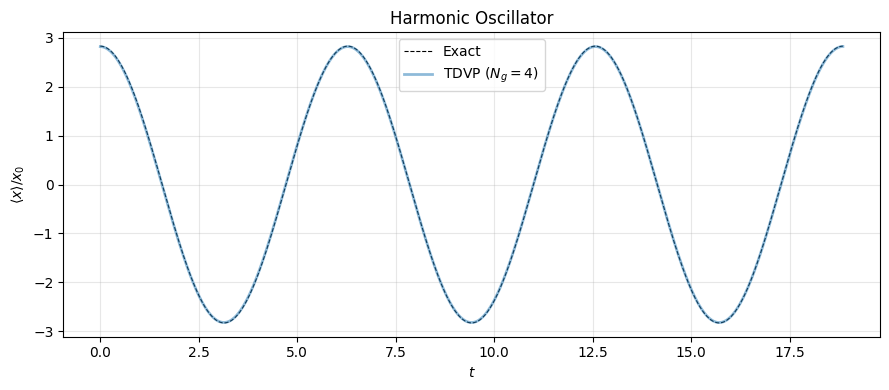

In [5]:
omega=1.0; alpha0=2.0+0j; NGAUSS=4; T=3*2*np.pi; dt=0.01
psi = HierarchicalState()
psi.add_gaussian('g', make_gaussians(alpha0, NGAUSS))
nus = make_nus(['g'], NGAUSS, 1)
t, zs, solver = evolve(psi, nus, [(omega,'g','g',{0:(1,1)})], [], T, dt)

x_tdvp = [np.sqrt(2)*np.real(get_expec(z,solver,'g',0,0,1)) for z in zs]
x_exact = np.sqrt(2)*np.abs(alpha0)*np.cos(omega*t)

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t, x_exact, 'k--', lw=0.8, label='Exact')
ax.plot(t, x_tdvp, alpha = 0.5, label=r'TDVP ($N_g=4$)')
ax.set_xlabel(r'$t$'); ax.set_ylabel(r'$\langle x\rangle/x_0$')
ax.set_title(r'Harmonic Oscillator'); ax.legend(); plt.tight_layout(); plt.show()


---
## 2. Single-mode Kerr
$H = \omega a^\dagger a + \frac{\chi}{2}(a^\dagger a)^2$, using $(a^\dagger a)^2 = a^{\dagger 2}a^2 + a^\dagger a$.  
Shows collapse and revival of $|\langle a\rangle|$. 6 Gaussians.


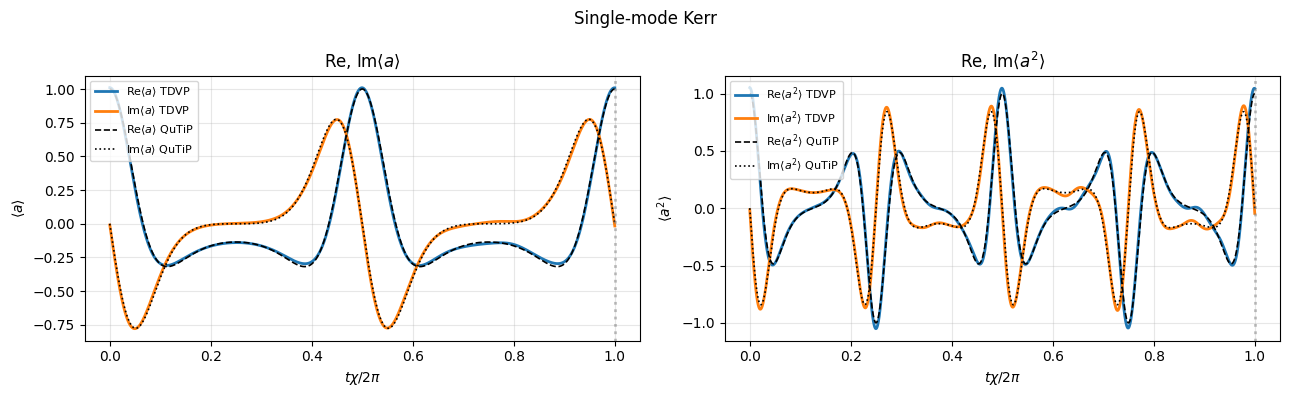

In [9]:
omega=1.0; chi=1.0; alpha0=1.0+0j; NGAUSS=4
T=2*np.pi/chi; dt=1e-4
psi = HierarchicalState()
psi.add_gaussian('g', make_gaussians(alpha0, NGAUSS, seed=1))
nus = make_nus(['g'], NGAUSS, 1)
H = [(omega+chi,'g','g',{0:(1,1)}), (chi,'g','g',{0:(2,2)})]
t, zs, solver = evolve(psi, nus, H, [], T, dt)
a_tdvp  = np.array([get_expec(z,solver,'g',0,0,1) for z in zs])
a2_tdvp = np.array([get_expec(z,solver,'g',0,0,2) for z in zs])
print('TDVP done.')
try:
    import qutip as qt
    N=25; a_op=qt.destroy(N)
    res = qt.sesolve(omega*a_op.dag()*a_op + chi*(a_op.dag()*a_op)**2,
                     qt.coherent(N,alpha0), t, e_ops=[a_op, a_op*a_op])
    a_qt  = res.expect[0]
    a2_qt = res.expect[1]
    has_qt=True
except: has_qt=False

fig, axes = plt.subplots(1,2,figsize=(13,4))

# --- Re/Im <a> ---
axes[0].plot(t*chi/(2*np.pi), np.real(a_tdvp), label=r'Re$\langle a\rangle$ TDVP')
axes[0].plot(t*chi/(2*np.pi), np.imag(a_tdvp), label=r'Im$\langle a\rangle$ TDVP')
if has_qt:
    axes[0].plot(t*chi/(2*np.pi), np.real(a_qt), 'k--', lw=1.2, label=r'Re$\langle a\rangle$ QuTiP')
    axes[0].plot(t*chi/(2*np.pi), np.imag(a_qt), 'k:', lw=1.2,  label=r'Im$\langle a\rangle$ QuTiP')
axes[0].axvline(1.0, color='gray', ls=':', alpha=0.5)
axes[0].set_xlabel(r'$t\chi/2\pi$'); axes[0].set_ylabel(r'$\langle a\rangle$')
axes[0].set_title(r'Re, Im$\langle a\rangle$'); axes[0].legend(fontsize=8)

# --- Re/Im <a^2> ---
axes[1].plot(t*chi/(2*np.pi), np.real(a2_tdvp), label=r'Re$\langle a^2\rangle$ TDVP')
axes[1].plot(t*chi/(2*np.pi), np.imag(a2_tdvp), label=r'Im$\langle a^2\rangle$ TDVP')
if has_qt:
    axes[1].plot(t*chi/(2*np.pi), np.real(a2_qt), 'k--', lw=1.2, label=r'Re$\langle a^2\rangle$ QuTiP')
    axes[1].plot(t*chi/(2*np.pi), np.imag(a2_qt), 'k:', lw=1.2,  label=r'Im$\langle a^2\rangle$ QuTiP')
axes[1].axvline(1.0, color='gray', ls=':', alpha=0.5)
axes[1].set_xlabel(r'$t\chi/2\pi$'); axes[1].set_ylabel(r'$\langle a^2\rangle$')
axes[1].set_title(r'Re, Im$\langle a^2\rangle$'); axes[1].legend(fontsize=8)

fig.suptitle('Single-mode Kerr'); plt.tight_layout(); plt.show()


---
## 3. Cross-Kerr
$H = \chi\, n_1 n_2$.  
to demonstrate capability of cross-mode dynamics.

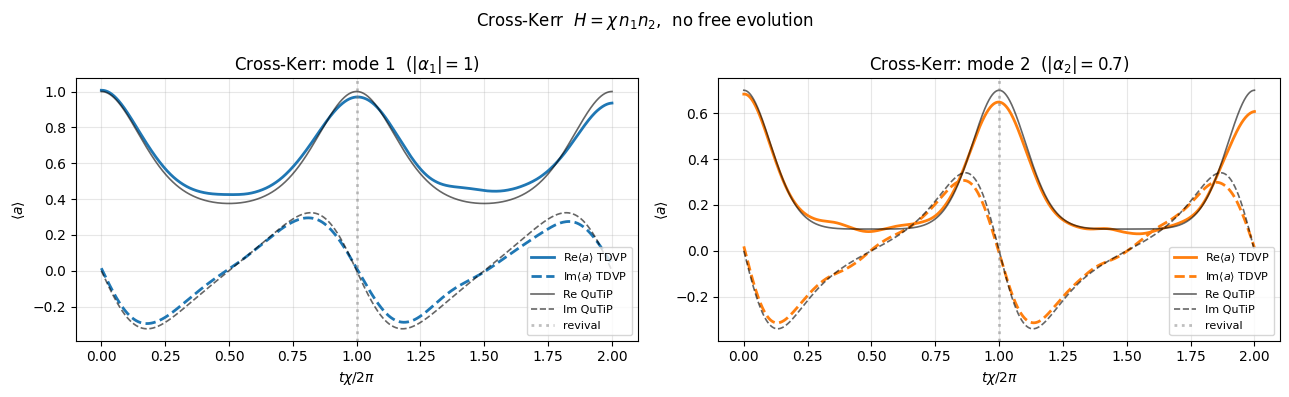

In [25]:

chi=1.0; alpha1=1.0+0j; alpha2=0.7+0j; NGAUSS=8
T=2*np.pi/chi * 2; dt=0.1e-3
psi = HierarchicalState()
psi.add_gaussian('g', make_gaussians([alpha1,alpha2], NGAUSS, seed=2))
nus = make_nus(['g'], NGAUSS, 2)
# pure cross-Kerr: H = chi * n1 * n2
H = [(chi,'g','g',{0:(1,1),1:(1,1)})]
t, zs, solver = evolve(psi, nus, H, [], T, dt)
a1_tdvp = np.array([get_expec(z,solver,'g',0,0,1) for z in zs])
a2_tdvp = np.array([get_expec(z,solver,'g',1,0,1) for z in zs])

try:
    import qutip as qt
    N=20; a=qt.tensor(qt.destroy(N),qt.qeye(N)); b=qt.tensor(qt.qeye(N),qt.destroy(N))
    psi0 = qt.tensor(qt.coherent(N,alpha1), qt.coherent(N,alpha2))
    res = qt.sesolve(chi*a.dag()*a*b.dag()*b, psi0, t, e_ops=[a,b])
    a1_qt=res.expect[0]; a2_qt=res.expect[1]; has_qt=True
except: has_qt=False

fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, a_t, a_q, label, c in [
    (axes[0], a1_tdvp, a1_qt if has_qt else None, r'mode 1  ($|\alpha_1|=1$)', 'C0'),
    (axes[1], a2_tdvp, a2_qt if has_qt else None, r'mode 2  ($|\alpha_2|=0.7$)', 'C1')]:
    ax.plot(t*chi/(2*np.pi), np.real(a_t), color=c,    label=r'Re$\langle a\rangle$ TDVP')
    ax.plot(t*chi/(2*np.pi), np.imag(a_t), color=c, ls='--', label=r'Im$\langle a\rangle$ TDVP')
    if a_q is not None:
        ax.plot(t*chi/(2*np.pi), np.real(a_q), 'k-',  lw=1.2, alpha=0.6, label='Re QuTiP')
        ax.plot(t*chi/(2*np.pi), np.imag(a_q), 'k--', lw=1.2, alpha=0.6, label='Im QuTiP')
    ax.axvline(1.0, color='gray', ls=':', alpha=0.5, label='revival')
    ax.set_xlabel(r'$t\chi/2\pi$'); ax.set_ylabel(r'$\langle a\rangle$')
    ax.set_title(f'Cross-Kerr: {label}'); ax.legend(fontsize=8)
fig.suptitle(r'Cross-Kerr  $H=\chi\, n_1 n_2$,  no free evolution')
plt.tight_layout(); plt.show()

---
## 4. Non-Hermitian: Norm Decay
$K = \frac{\Gamma}{2}\sigma_{ee}$, no Hamiltonian. Norm decays as $e^{-\Gamma t}$ for $P_e(0)=1$.


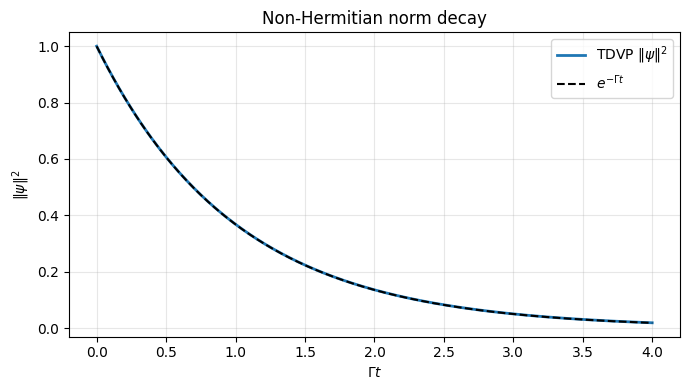

In [22]:
Gamma=1.0; NGAUSS=2; T=4.0; dt=0.01

def norm_psi(psi):
    return sum(np.real(np.exp(gi.kappa+gj.kappa+1j*(gj.theta-gi.theta))*
               single_mode_gaussians_expec(gi.alpha[0],gi.beta[0],gj.alpha[0],gj.beta[0],0,0))
               for gs in psi.state.values() for gi in gs for gj in gs)

psi = HierarchicalState()
psi.add_gaussian('e', make_gaussians(1.0+0j, NGAUSS, suppress=0.0, seed=0))
psi.add_gaussian('g', make_gaussians(0.0+0j, NGAUSS, suppress=4.0, seed=1))
nus = make_nus(['e','g'], NGAUSS, 1)
solver = TDVPSolver(psi, nus, [], K_terms=[(Gamma/2,'e','e',{})])
z = pack_state(psi, nus)
n_steps = int(T/dt); t = np.linspace(0,T,n_steps+1)
norms = [norm_psi(psi)]
for _ in range(n_steps):
    z = rk4_step(z, dt, solver)
    norms.append(norm_psi(psi))

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(t, norms, label=r'TDVP $\|\psi\|^2$')
ax.plot(t, np.exp(-Gamma*t), 'k--', lw=1.5, label=r'$e^{-\Gamma t}$')
ax.set_xlabel(r'$\Gamma t$'); ax.set_ylabel(r'$\|\psi\|^2$')
ax.set_title('Non-Hermitian norm decay'); ax.legend()
plt.tight_layout(); plt.show()
